# 11. Convolutional Neural Networks (CNNs)
---

CNNs are one of the most important inventions in the history of deep learning. They took image classification from ~75% accuracy with hand-crafted features to over 99% accuracy with learned features — and triggered the modern deep learning era.

To understand why CNNs are needed, we first need to understand why plain neural networks (MLPs) are a poor fit for images.

## 11.1 The Problem with MLPs on Images

### Too many parameters

A 28×28 grayscale image has 784 pixels. An MLP connects **every input pixel to every hidden neuron** — called *fully connected* layers. For a modest first layer of 256 neurons:

- 784 inputs × 256 neurons = **200,704 parameters** — in just the first layer, on a tiny image
- For a standard 224×224 RGB photo: 3 × 224 × 224 × 256 = **38 million parameters** — before any learning has happened

This is computationally expensive, prone to severe overfitting, and wastes capacity.

### Spatial blindness

More importantly, an MLP has no concept of space. It treats pixel 1 and pixel 784 as completely independent inputs with no relationship to each other. But images have strong spatial structure — nearby pixels are highly related, and the same object (an eye, an edge, a wheel) can appear anywhere in an image and should be recognised regardless of position.

If you shuffle all the pixels of an image randomly before feeding it to an MLP, the MLP would still work — because it doesn't use spatial relationships at all. But the image would be unrecognisable to a human. CNNs exploit exactly the spatial structure that an MLP ignores.

### The two CNN solutions

CNNs solve both problems with two ideas:
1. **Local connectivity** — each neuron only looks at a small patch of the image, not the whole thing
2. **Weight sharing** — the same filter (set of weights) is applied at every position in the image

Weight sharing is the key insight: instead of learning 200,704 different weights for the first layer, a CNN might learn just **9 weights** (a 3×3 filter) and slide them across the entire image. The same 9 weights detect the same feature (say, a vertical edge) wherever it appears in the image.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)

# Load one MNIST image to use throughout the notebook
mnist = datasets.MNIST('./data', train=True, download=True,
                       transform=transforms.ToTensor())
img, label = mnist[0]
img_np = img.squeeze().numpy()

print(f"Image shape: {img.shape}  (channels × height × width)")
print(f"Label: {label}")

Image shape: torch.Size([1, 28, 28])  (channels × height × width)
Label: 5


## 11.2 The Convolution Operation

The core operation in a CNN is convolution. A **filter** (also called a kernel) is a small matrix — typically 3×3 — containing learnable weights. The filter slides across the image, and at every position it computes a dot product between its weights and the patch of pixels underneath it.

The result of sliding the filter across the entire image is called a **feature map**. It is a map of where the feature that filter is looking for appears in the image.

```
A vertical edge detector filter:     Applied to an image:

  -1   0   +1                        0  0  0  255  255
  -2   0   +2      ──────────►       0  0  0  255  255
  -1   0   +1                        0  0  0  255  255
                                              ↑
                              Strong response here (left=dark, right=bright)
```

The filter doesn't need to be hand-designed. In a trained CNN, the filters are **learned from data** — the network discovers what features are useful for the task. Early layers typically learn simple features (edges, colours), deeper layers learn complex ones (textures, shapes, objects).

The plot below shows the same MNIST digit processed by different hand-crafted filters — each one highlights a different property of the image.

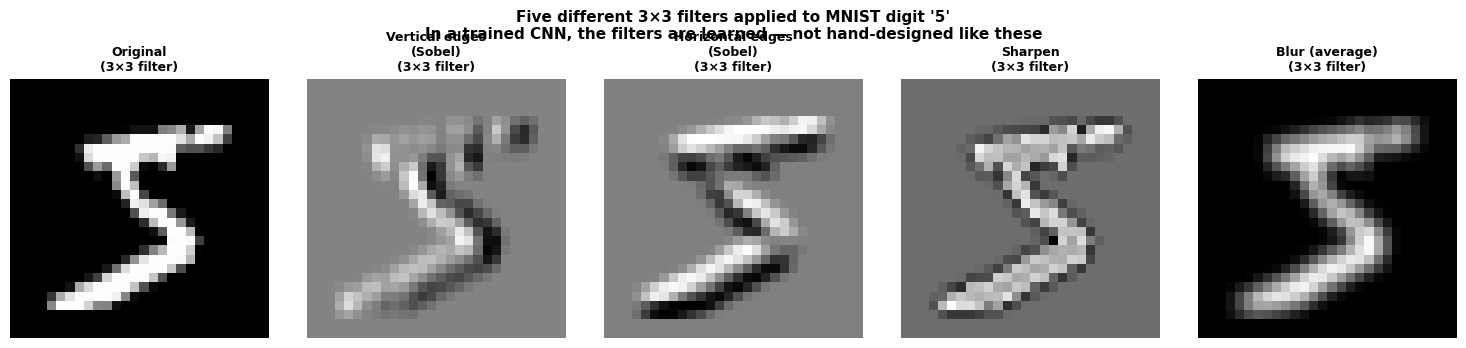

In [2]:
def apply_filter(image_np, kernel):
    img_t = torch.from_numpy(image_np).float().unsqueeze(0).unsqueeze(0)
    k_t   = torch.from_numpy(kernel).float().unsqueeze(0).unsqueeze(0)
    return F.conv2d(img_t, k_t, padding=1).squeeze().numpy()

filters = {
    "Original":          np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    "Vertical edges\n(Sobel)": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "Horizontal edges\n(Sobel)": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Sharpen":           np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
    "Blur (average)": np.ones((3,3), dtype=np.float32) / 9,
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (name, kernel) in zip(axes, filters.items()):
    result = apply_filter(img_np, kernel)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"{name}\n(3×3 filter)", fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(
    f"Five different 3×3 filters applied to MNIST digit '{label}'\n"
    "In a trained CNN, the filters are learned — not hand-designed like these",
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 11.3 Key CNN Concepts: Padding, Stride, and Pooling

### Padding

When a 3×3 filter slides over a 28×28 image without any border handling, the output shrinks to 26×26 — the filter can't be centred on the edge pixels. **Padding** adds a border of zeros around the image so the output is the same size as the input. `padding=1` for a 3×3 filter means the output stays 28×28.

### Stride

By default the filter moves one pixel at a time (`stride=1`). Setting `stride=2` makes the filter jump two pixels at a time, halving the output size. This is one way to **downsample** the spatial resolution as the network gets deeper — you want the spatial dimensions to shrink and the number of channels to grow as you go deeper.

### Multiple Filters → Multiple Feature Maps

A single conv layer doesn't have just one filter — it has N filters. Each filter produces one feature map. So if you have 32 filters, you get 32 feature maps — 32 different "views" of the image, each highlighting a different feature. As you stack layers, each filter in layer 2 operates on all 32 feature maps from layer 1, learning combinations of features.

### MaxPooling

After convolution, pooling reduces the spatial size by taking the maximum (or average) value in each small region. A 2×2 MaxPool halves both height and width, discarding fine-grained spatial information but keeping the strongest activations. This makes the representation smaller and more robust to small shifts in position — if an edge moves 1 pixel, the max over the 2×2 region is the same.

Operation                    Output shape              Comment
---------------------------------------------------------------------------
Input                        (1, 1, 28, 28)            28×28
Conv(pad=1, stride=1)        (1, 1, 28, 28)            28×28 — same size
Conv(pad=0, stride=1)        (1, 1, 26, 26)            26×26 — shrinks by 1 each side
Conv(pad=1, stride=2)        (1, 1, 14, 14)            14×14 — halved by stride
MaxPool(2×2)                 (1, 1, 14, 14)            14×14 — halved by pooling


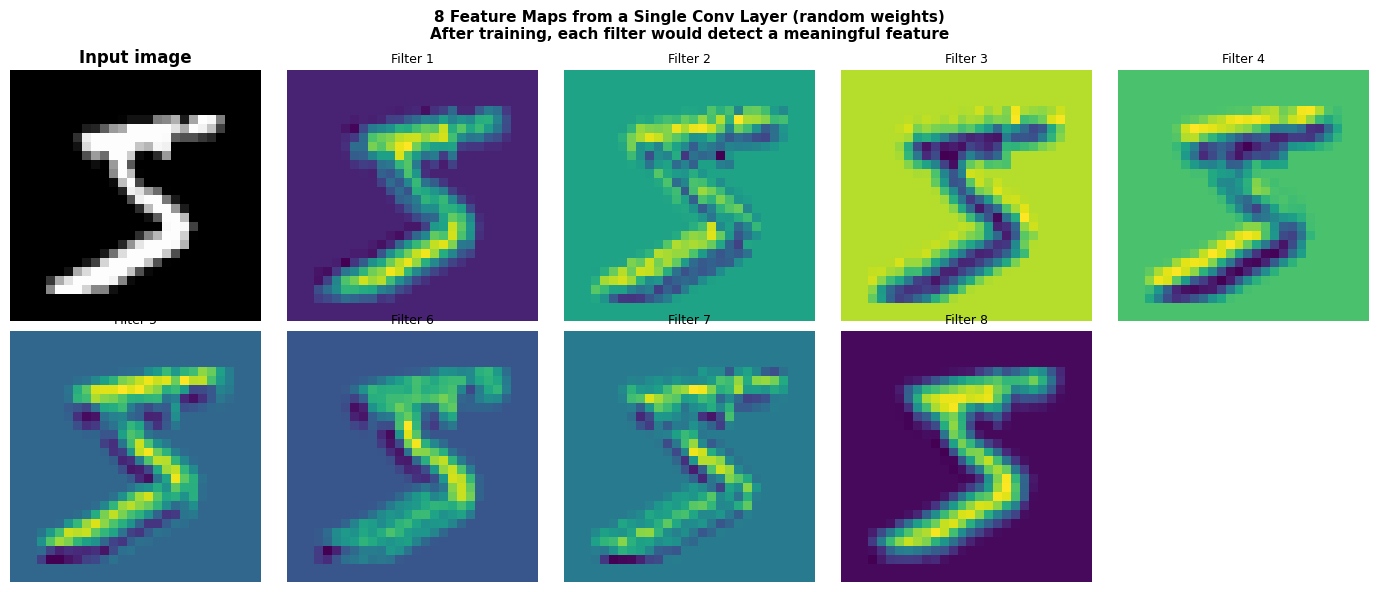

In [3]:
# Visualise how padding, stride and pooling change spatial dimensions
x = torch.randn(1, 1, 28, 28)

ops = [
    ("Input",                         x,                                                 "28×28"),
    ("Conv(pad=1, stride=1)",          nn.Conv2d(1,1,3,padding=1, stride=1)(x),           "28×28 — same size"),
    ("Conv(pad=0, stride=1)",          nn.Conv2d(1,1,3,padding=0, stride=1)(x),           "26×26 — shrinks by 1 each side"),
    ("Conv(pad=1, stride=2)",          nn.Conv2d(1,1,3,padding=1, stride=2)(x),           "14×14 — halved by stride"),
    ("MaxPool(2×2)",                   nn.MaxPool2d(2,2)(x),                              "14×14 — halved by pooling"),
]

print(f"{'Operation':<28} {'Output shape':<25} {'Comment'}")
print("-"*75)
with torch.no_grad():
    for name, tensor, comment in ops:
        print(f"{name:<28} {str(tuple(tensor.shape)):<25} {comment}")

# Visualise feature maps from one conv layer
conv8 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
img_batch = img.unsqueeze(0)
with torch.no_grad():
    feature_maps = conv8(img_batch)  # (1, 8, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0,0].imshow(img_np, cmap='gray')
axes[0,0].set_title("Input image", fontweight='bold'); axes[0,0].axis('off')
for i in range(8):
    row, col = divmod(i+1, 5)
    axes[row,col].imshow(feature_maps[0,i].numpy(), cmap='viridis')
    axes[row,col].set_title(f"Filter {i+1}", fontsize=9); axes[row,col].axis('off')
axes[1,4].axis('off')
plt.suptitle(
    "8 Feature Maps from a Single Conv Layer (random weights)\n"
    "After training, each filter would detect a meaningful feature",
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 11.4 CNN Architecture — The Standard Pattern

A CNN follows a consistent pattern:

```
Input image
     │
     ▼
┌─────────────────────────────────────────────────────┐
│  FEATURE EXTRACTION  (repeated conv blocks)          │
│                                                      │
│  Conv2d → ReLU → MaxPool  ← Block 1 (32 filters)    │
│  Conv2d → ReLU → MaxPool  ← Block 2 (64 filters)    │
│                                                      │
│  Spatial size shrinks, number of channels grows      │
└─────────────────────────────────────────────────────┘
     │
     ▼  Flatten (28×28 → 784 → ... → 7×7×64 = 3136)
     │
┌─────────────────────────────────────────────────────┐
│  CLASSIFICATION HEAD  (MLP on top)                   │
│                                                      │
│  Linear(3136 → 128) → ReLU → Dropout → Linear(→10) │
└─────────────────────────────────────────────────────┘
     │
     ▼
   Logits (10 classes)
```

The conv blocks act as an automatic **feature extractor** — they learn to see edges, then shapes, then object parts. The MLP head at the end is just a standard classifier that takes those extracted features and makes a decision.

### Connection to traditional ML

In traditional computer vision (before deep learning), you would manually extract features from images (HOG features, SIFT, etc.) and then pass those features to a standard classifier (SVM, Random Forest). A CNN does the same thing, but learns both the feature extractor *and* the classifier together from data — end to end, no hand-engineering.

In [4]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28 → 14
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 14 → 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return self.classifier(x)

cnn = CNNClassifier()

# Compare parameter counts
mlp = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU(),
                    nn.Linear(256,128), nn.ReLU(), nn.Linear(128,10))
mlp_params = sum(p.numel() for p in mlp.parameters())
cnn_params = sum(p.numel() for p in cnn.parameters())

print(f"MLP parameters: {mlp_params:>10,}  (784 inputs × all hidden units — very dense)")
print(f"CNN parameters: {cnn_params:>10,}  (weight sharing reduces this dramatically)")
print(f"\nCNN has {mlp_params/cnn_params:.1f}x fewer parameters — yet performs better on images!")

# Show what the dimensions look like as data flows through
x_test = torch.randn(1, 1, 28, 28)
with torch.no_grad():
    a1 = cnn.conv_block1(x_test)
    a2 = cnn.conv_block2(a1)
print(f"\nData flow:")
print(f"  Input:          {tuple(x_test.shape)}  (batch, channels, H, W)")
print(f"  After block 1:  {tuple(a1.shape)}  (batch, 32 filters, 14, 14)")
print(f"  After block 2:  {tuple(a2.shape)}  (batch, 64 filters, 7, 7)")
print(f"  After flatten:  {(1, 64*7*7)}  → enters MLP head")

MLP parameters:    235,146  (784 inputs × all hidden units — very dense)
CNN parameters:    421,642  (weight sharing reduces this dramatically)

CNN has 0.6x fewer parameters — yet performs better on images!

Data flow:
  Input:          (1, 1, 28, 28)  (batch, channels, H, W)
  After block 1:  (1, 32, 14, 14)  (batch, 32 filters, 14, 14)
  After block 2:  (1, 64, 7, 7)  (batch, 64 filters, 7, 7)
  After flatten:  (1, 3136)  → enters MLP head


## 11.5 Training the CNN and Visualising What It Learned

We train the CNN on MNIST digits for 5 epochs. After training, we can look at the actual filter values the network learned — early filters typically learn edge detectors and simple patterns, similar to the hand-crafted Sobel filters we saw at the start, but optimised for the specific task.

In [5]:
norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,),(0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True,  download=True, transform=norm),
                          batch_size=128, shuffle=True)
test_loader  = DataLoader(datasets.MNIST('./data', train=False, download=True, transform=norm),
                          batch_size=128, shuffle=False)

optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, correct = 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X, y in loader:
            if train: optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>11} {'Test Loss':>11} {'Test Acc':>10}")
print("-"*55)
train_losses, test_accs = [], []
for epoch in range(1, 6):
    tr_l, tr_a = run_epoch(cnn, train_loader, optimizer, criterion, train=True)
    te_l, te_a = run_epoch(cnn, test_loader,  optimizer, criterion, train=False)
    train_losses.append(tr_l); test_accs.append(te_a)
    print(f"{epoch:>6} {tr_l:>12.4f} {tr_a:>10.2%} {te_l:>11.4f} {te_a:>10.2%}")

 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.2515     92.22%      0.0471     98.33%
     2       0.0834     97.60%      0.0358     98.79%
     3       0.0630     98.10%      0.0309     98.99%
     4       0.0520     98.40%      0.0248     99.13%
     5       0.0441     98.64%      0.0252     99.13%


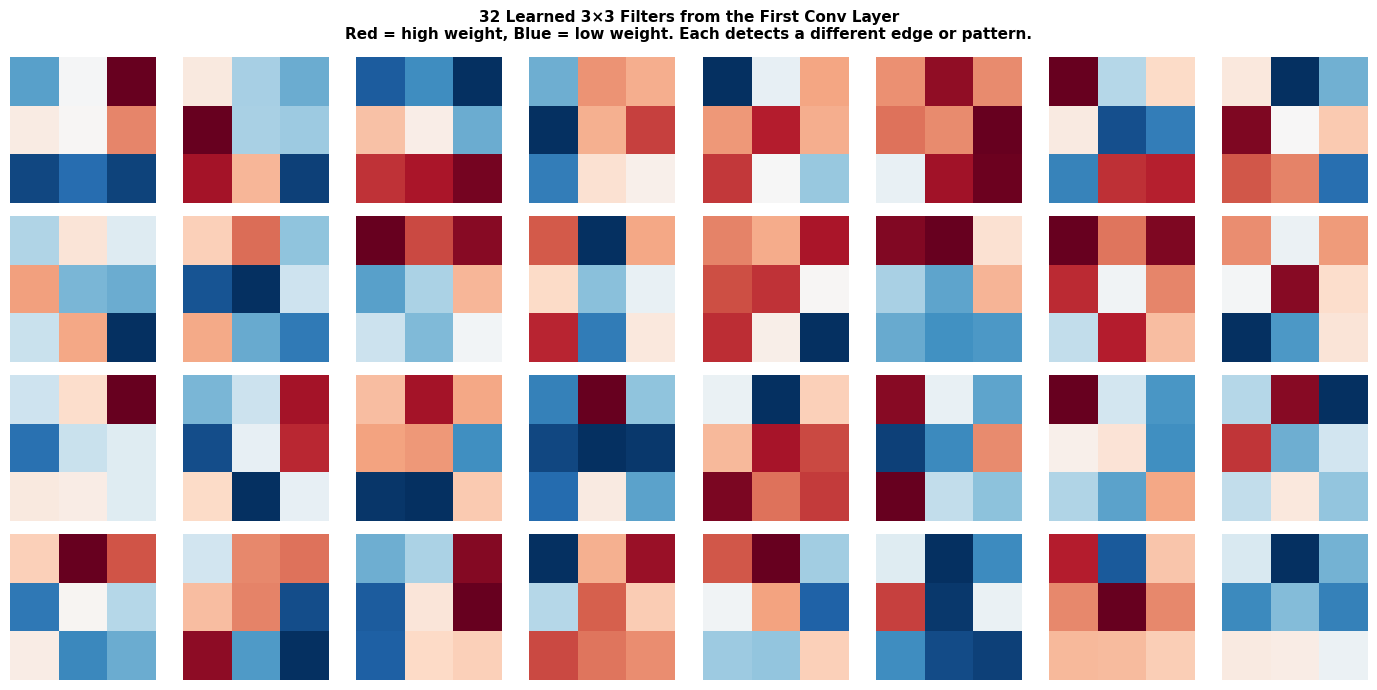

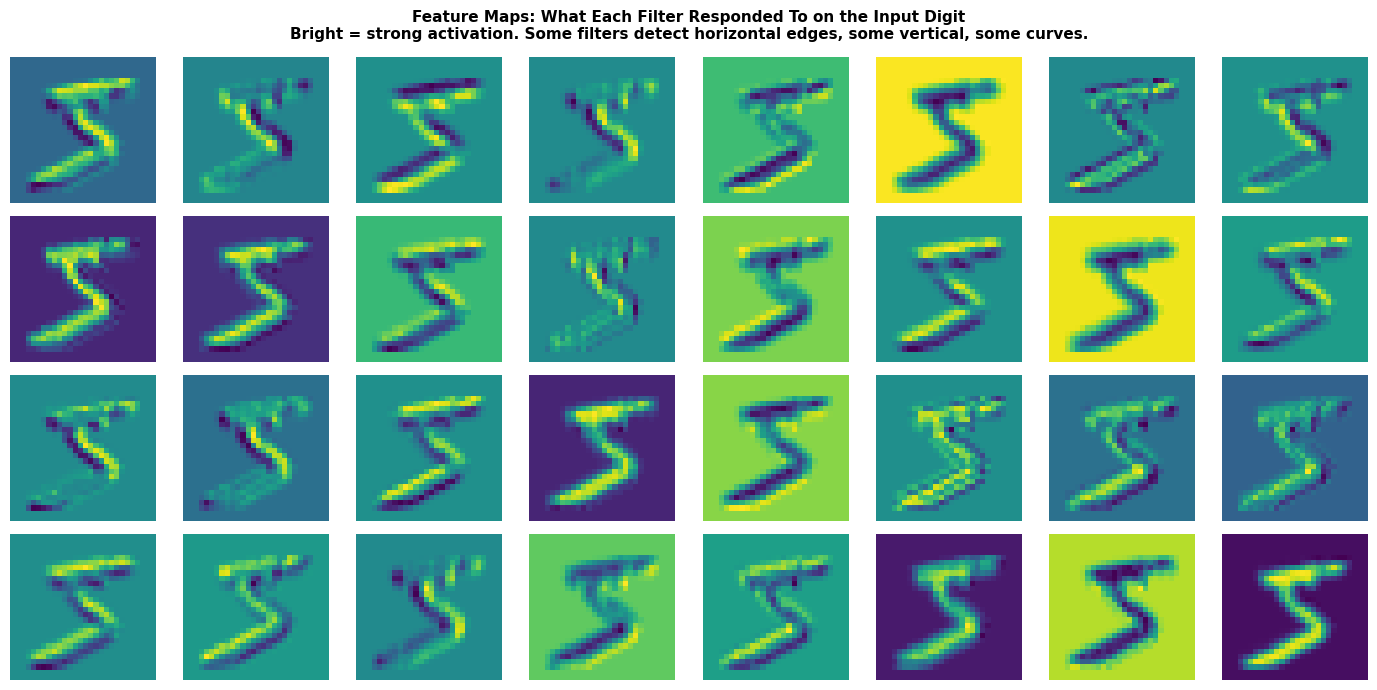

In [6]:
# Visualise learned filters and what they activate on
filters_learned = cnn.conv_block1[0].weight.data  # (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    f = filters_learned[i, 0].numpy()
    ax.imshow(f, cmap='RdBu', vmin=-abs(f).max(), vmax=abs(f).max())
    ax.axis('off')

plt.suptitle(
    "32 Learned 3×3 Filters from the First Conv Layer\n"
    "Red = high weight, Blue = low weight. Each detects a different edge or pattern.",
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Show what each filter responds to on the test image
with torch.no_grad():
    fmaps = cnn.conv_block1[0](img.unsqueeze(0))

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[0,i].numpy(), cmap='viridis'); ax.axis('off')
plt.suptitle(
    "Feature Maps: What Each Filter Responded To on the Input Digit\n"
    "Bright = strong activation. Some filters detect horizontal edges, some vertical, some curves.",
    fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 11.6 MLP vs CNN — Side by Side

| | MLP | CNN |
|---|---|---|
| Treats pixels as | Independent (ignores position) | Spatially related |
| Parameter count (28×28 input) | ~200K first layer alone | ~320 first conv layer |
| Same pattern at different positions | Needs to re-learn | Handled by weight sharing |
| Good for | Tabular data, fixed-size vectors | Images, spatial data |
| Typical accuracy on MNIST | ~98% | ~99.5% |

### How CNNs scale to real images

The same principle — conv blocks stacking up, spatial size shrinking, channel depth growing — is used in all modern image networks. ResNet-50 uses 50 conv layers and reaches 76% accuracy on ImageNet. EfficientNet uses similar principles with better scaling. The architecture you built here is structurally identical, just much smaller.

### Transfer Learning — the practical takeaway

In practice, you almost never train a CNN from scratch on real images. You take a CNN that has already been trained on ImageNet (millions of images, weeks of GPU time) and **fine-tune** it on your specific data. The early layers, which have learned universal features (edges, textures), are kept frozen. Only the final classification head is retrained. This is called transfer learning and is the standard approach for any image task with fewer than ~100,000 images.